<a href="https://colab.research.google.com/github/AhmedMahmoud-123/FlyRank_AI/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Which content items in a client's portfolio are declining in search
visibility right now, and can a model rank them for review more usefully than a simple,
hand-written rule?

**The decision this supports:** out of thousands of pages a client owns, a human editor can
only manually review a handful per week. This work produces a ranked queue — which page to
look at *first* — not a diagnosis of *why* a page declined, and not an automated fix. It's
decision-support for a content strategist's weekly review, same framing as the Week-4 baseline
and Week-7 action playbook, now built on the full warehouse instead of the 30k-row starter slice.

**Why this matters at warehouse scale:** the starter dataset was one static snapshot. The
warehouse lets this become a real per-client, per-window question — "declining relative to
that client's own recent history" — rather than one global cutoff applied to everyone,
which is the more honest version of the same problem.

In [1]:
import duckdb, getpass, os

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('HF read token: ')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':       f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':       f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily_sample': f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_daily_full':   f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_query_90d':    f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}
print(list(TABLES.keys()))

HF read token: ··········
['dim_clients', 'dim_content', 'fact_daily_sample', 'fact_daily_full', 'fact_query_90d']


In [2]:
scale = con.sql(f"""
    SELECT
        (SELECT COUNT(*) FROM {TABLES['dim_clients']}) AS n_clients,
        (SELECT COUNT(*) FROM {TABLES['dim_content']}) AS n_content_items
""").df()
print(scale)

   n_clients  n_content_items
0        104           519606


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [3]:
print("=== fact_content_daily_performance_sample ===")
print(con.sql(f"DESCRIBE SELECT * FROM {TABLES['fact_daily_sample']}").df())
print("\n=== dim_clients ===")
print(con.sql(f"DESCRIBE SELECT * FROM {TABLES['dim_clients']}").df())
print("\n=== dim_content ===")
print(con.sql(f"DESCRIBE SELECT * FROM {TABLES['dim_content']}").df())
print("\n=== fact_content_query_90d ===")
print(con.sql(f"DESCRIBE SELECT * FROM {TABLES['fact_query_90d']}").df())

=== fact_content_daily_performance_sample ===
                 column_name column_type null   key default extra
0                report_date        DATE  YES  None    None  None
1             client_hash_id     VARCHAR  YES  None    None  None
2            content_hash_id     VARCHAR  YES  None    None  None
3             client_has_gsc     BOOLEAN  YES  None    None  None
4             client_has_ga4     BOOLEAN  YES  None    None  None
5         gsc_data_available     BOOLEAN  YES  None    None  None
6         ga4_data_available     BOOLEAN  YES  None    None  None
7            gsc_impressions      BIGINT  YES  None    None  None
8                 gsc_clicks      BIGINT  YES  None    None  None
9           gsc_sum_position      BIGINT  YES  None    None  None
10          gsc_avg_position      DOUBLE  YES  None    None  None
11             ga4_pageviews      BIGINT  YES  None    None  None
12              ga4_sessions      BIGINT  YES  None    None  None
13                 ga4_users  

In [4]:
window_check = con.sql(f"""
    SELECT COUNT(DISTINCT window_start) AS n_starts, COUNT(DISTINCT window_end) AS n_ends,
           MIN(window_start) AS min_start, MAX(window_end) AS max_end
    FROM {TABLES['fact_query_90d']}
""").df()
print("query table window:", window_check)

full_span = con.sql(f"""
    SELECT MIN(report_date) AS min_d, MAX(report_date) AS max_d,
           COUNT(DISTINCT client_hash_id) AS n_clients
    FROM {TABLES['fact_daily_full']}
""").df()
print("full table span:", full_span)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

query table window:    n_starts  n_ends  min_start    max_end
0         1       1 2026-04-02 2026-06-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

full table span:        min_d      max_d  n_clients
0 2025-01-27 2026-06-30         70


In [5]:
def build_labeled_features(fact_table: str, min_prev30_impressions: int = 100):
    return con.sql(f"""
        WITH client_anchor AS (
            SELECT client_hash_id, MAX(report_date) AS anchor_date
            FROM {fact_table}
            WHERE gsc_data_available = TRUE
            GROUP BY client_hash_id
        ),
        eligible AS (
            SELECT ca.client_hash_id, ca.anchor_date
            FROM client_anchor ca
            JOIN {TABLES['dim_clients']} c ON c.client_hash_id = ca.client_hash_id
            WHERE c.gsc_data_start <= ca.anchor_date - INTERVAL 59 DAY
              AND c.is_active = TRUE
        ),
        windowed AS (
            SELECT
                f.client_hash_id,
                f.content_hash_id,
                e.anchor_date,
                SUM(CASE WHEN f.report_date > e.anchor_date - INTERVAL 30 DAY
                          AND f.gsc_data_available = TRUE
                         THEN f.gsc_impressions ELSE 0 END) AS impressions_last30,
                SUM(CASE WHEN f.report_date <= e.anchor_date - INTERVAL 30 DAY
                          AND f.report_date > e.anchor_date - INTERVAL 60 DAY
                          AND f.gsc_data_available = TRUE
                         THEN f.gsc_impressions ELSE 0 END) AS impressions_prev30,
                AVG(CASE WHEN f.report_date <= e.anchor_date - INTERVAL 30 DAY
                          AND f.report_date > e.anchor_date - INTERVAL 60 DAY
                          AND f.gsc_data_available = TRUE
                         THEN f.gsc_avg_position END) AS avg_position_prev30
            FROM {fact_table} f
            JOIN eligible e ON e.client_hash_id = f.client_hash_id
            WHERE f.report_date > e.anchor_date - INTERVAL 60 DAY
            GROUP BY 1, 2, 3
        )
        SELECT w.*,
            dc.content_created_date,
            dc.content_updated_date,
            (dc.content_created_date <= w.anchor_date - INTERVAL 59 DAY) AS content_old_enough,
            CASE
               WHEN dc.content_updated_date <= w.anchor_date
               THEN DATE_DIFF('day', dc.content_updated_date, w.anchor_date)
               ELSE NULL
            END AS days_since_last_update,
            (hash(w.client_hash_id) % 1000) < 250 AS is_test_client,
            CASE
                WHEN w.impressions_prev30 = 0 AND w.impressions_last30 = 0 THEN 'flat'
                WHEN w.impressions_prev30 = 0 AND w.impressions_last30 > 0 THEN 'new'
                WHEN (w.impressions_last30 - w.impressions_prev30) * 1.0 / NULLIF(w.impressions_prev30, 0) < -0.20 THEN 'down'
                WHEN (w.impressions_last30 - w.impressions_prev30) * 1.0 / NULLIF(w.impressions_prev30, 0) > 0.20 THEN 'up'
                ELSE 'stable'
            END AS trend_direction
        FROM windowed w
        JOIN {TABLES['dim_content']} dc ON dc.content_hash_id = w.content_hash_id
        WHERE w.impressions_prev30 >= {min_prev30_impressions}
          AND dc.is_deleted = FALSE
          AND dc.is_published = TRUE
    """).df()

features_full = build_labeled_features(TABLES['fact_daily_full'])
features_full = features_full[features_full['content_old_enough']]
features_full['is_declining_label'] = (features_full['trend_direction'] == 'down').astype(int)

print(f"{len(features_full):,} eligible rows")
print(features_full['trend_direction'].value_counts())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

93,401 eligible rows
trend_direction
down      62428
stable    16344
up        14629
Name: count, dtype: int64


In [6]:
for floor in [100, 250, 500, 1000, 2500]:
    subset = features_full[features_full['impressions_prev30'] >= floor]
    print(f"floor={floor:>5}  n={len(subset):>6,}  decline_rate={subset['is_declining_label'].mean():.3f}")

floor=  100  n=93,401  decline_rate=0.668
floor=  250  n=68,870  decline_rate=0.669
floor=  500  n=51,088  decline_rate=0.669
floor= 1000  n=35,689  decline_rate=0.664
floor= 2500  n=19,614  decline_rate=0.658


In [7]:
def build_query_features():
    return con.sql(f"""
        WITH per_query AS (
            SELECT
                client_hash_id,
                content_hash_id,
                impressions_prev30,
                impressions_prev30 * 1.0
                    / NULLIF(
                        SUM(impressions_prev30) OVER (
                            PARTITION BY client_hash_id, content_hash_id
                        ),
                        0
                    ) AS query_share_prev30,
                content_visible_query_count,
                rare_impressions_share,
                anonymized_impressions_share
            FROM {TABLES['fact_query_90d']}
            WHERE window_end = DATE '2026-06-30'
        )
        SELECT
            client_hash_id,
            content_hash_id,
            ANY_VALUE(content_visible_query_count) AS visible_queries,
            ANY_VALUE(rare_impressions_share) AS rare_share,
            ANY_VALUE(anonymized_impressions_share) AS anon_share,
            SUM(impressions_prev30) AS query_impressions_prev30,
            SUM(POWER(query_share_prev30, 2))
                AS query_concentration_prev30
        FROM per_query
        GROUP BY client_hash_id, content_hash_id
    """).df()


In [8]:
query_features = build_query_features()

print(
    f"{len(query_features):,} content items have aligned query-level features"
)

dupe_check = query_features.duplicated(
    subset=['client_hash_id', 'content_hash_id']
).sum()

print(f"duplicate (client, content) pairs: {dupe_check}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

133,852 content items have aligned query-level features
duplicate (client, content) pairs: 0


In [9]:
before_merge = len(features_full)

final = features_full.merge(
    query_features,
    on=['client_hash_id', 'content_hash_id'],
    how='left'
)

after_merge = len(final)

print(
    f"rows before merge: {before_merge:,}   "
    f"after merge: {after_merge:,}"
)

print(
    f"{final['visible_queries'].notna().mean():.1%} "
    "of rows have aligned query-level features"
)

rows before merge: 93,401   after merge: 93,401
92.6% of rows have aligned query-level features


In [10]:
print("Missing query features:")
print(
    final[
        ['visible_queries', 'rare_share', 'anon_share',
         'query_impressions_prev30', 'query_concentration_prev30']
    ].isna().mean().sort_values()
)

Missing query features:
visible_queries               0.073575
rare_share                    0.073575
anon_share                    0.073575
query_impressions_prev30      0.073575
query_concentration_prev30    0.094078
dtype: float64


In [11]:
print("Rows with query features:")
print(f"  All query features present: {final['query_concentration_prev30'].notna().sum():,}")
print(f"  Any query feature missing: {final[['visible_queries', 'rare_share', 'anon_share', 'query_impressions_prev30', 'query_concentration_prev30']].isna().any(axis=1).sum():,}")

print("\nRows with zero query impressions:")
print(
    (final['query_impressions_prev30'] == 0).sum()
)

Rows with query features:
  All query features present: 84,614
  Any query feature missing: 8,787

Rows with zero query impressions:
1915


In [12]:
conc_missing = final['query_concentration_prev30'].isna()

print("Rows with missing concentration:", conc_missing.sum())

print("\nAmong those rows:")
print(
    "query_impressions_prev30 missing:",
    final.loc[conc_missing, 'query_impressions_prev30'].isna().sum()
)

print(
    "query_impressions_prev30 == 0:",
    (final.loc[conc_missing, 'query_impressions_prev30'] == 0).sum()
)

print(
    "query_impressions_prev30 > 0:",
    (final.loc[conc_missing, 'query_impressions_prev30'] > 0).sum()
)

Rows with missing concentration: 8787

Among those rows:
query_impressions_prev30 missing: 6872
query_impressions_prev30 == 0: 1915
query_impressions_prev30 > 0: 0


In [13]:
# Query-feature alignment audit
assert after_merge == before_merge, (
    "Merge changed row count — possible duplicate keys."
)

assert dupe_check == 0, (
    "query_features contains duplicate (client, content) pairs."
)

missing_conc = final['query_concentration_prev30'].isna()

assert (
    final.loc[missing_conc, 'query_impressions_prev30'].isna()
    | (final.loc[missing_conc, 'query_impressions_prev30'] == 0)
).all(), (
    "Some rows have missing concentration despite positive query impressions."
)

positive_query_impressions_with_missing_conc = (
    final['query_impressions_prev30'].gt(0)
    & final['query_concentration_prev30'].isna()
).sum()

print(
    "Positive query impressions + missing concentration:",
    positive_query_impressions_with_missing_conc
)

print(
    f"Query features matched: "
    f"{final['visible_queries'].notna().mean():.1%}"
)

print(
    f"Rows with no usable query impressions: "
    f"{(
        final['query_impressions_prev30'].isna()
        | final['query_impressions_prev30'].eq(0)
    ).sum():,}"
)

Positive query impressions + missing concentration: 0
Query features matched: 92.6%
Rows with no usable query impressions: 8,787


In [14]:
final = final.copy()

final['has_query_signal'] = (
    final['query_impressions_prev30'].fillna(0) > 0
).astype(int)

y = final['is_declining_label'].astype(int)
is_test = final['is_test_client'].astype(bool)

print(f"Train rows: {(~is_test).sum():,}")
print(f"Test rows:  {is_test.sum():,}")
print(f"Test positives: {y[is_test].sum():,}")
print(f"Test base rate: {y[is_test].mean():.3f}")

Train rows: 68,798
Test rows:  24,603
Test positives: 18,175
Test base rate: 0.739


In [15]:
baseline_features = [
    'impressions_prev30',
    'avg_position_prev30',
    'days_since_last_update'
]

query_features = baseline_features + [
    'visible_queries',
    'rare_share',
    'anon_share',
    'query_impressions_prev30',
    'query_concentration_prev30',
    'has_query_signal'
]

print("Baseline features:", baseline_features)
print("Query-enhanced features:", query_features)

Baseline features: ['impressions_prev30', 'avg_position_prev30', 'days_since_last_update']
Query-enhanced features: ['impressions_prev30', 'avg_position_prev30', 'days_since_last_update', 'visible_queries', 'rare_share', 'anon_share', 'query_impressions_prev30', 'query_concentration_prev30', 'has_query_signal']


In [16]:
import numpy as np

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score


def precision_at_k(scores, labels, k):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    k = min(k, len(labels))

    order = np.argsort(-scores)

    return labels[order[:k]].mean()


def evaluate(feature_cols, label):

    X = final[feature_cols]

    model = HistGradientBoostingClassifier(
        random_state=42
    )

    model.fit(
        X.loc[~is_test],
        y.loc[~is_test]
    )

    probs = model.predict_proba(
        X.loc[is_test]
    )[:, 1]

    auc = roc_auc_score(
        y.loc[is_test],
        probs
    )

    p20 = precision_at_k(
        probs,
        y.loc[is_test].values,
        20
    )

    p50 = precision_at_k(
        probs,
        y.loc[is_test].values,
        50
    )

    p100 = precision_at_k(
        probs,
        y.loc[is_test].values,
        100
    )

    print(
        f"{label:40} "
        f"AUC={auc:.3f} "
        f"P@20={p20:.3f} "
        f"P@50={p50:.3f} "
        f"P@100={p100:.3f}"
    )

    return model, probs

In [17]:
baseline_cols = ['impressions_prev30', 'avg_position_prev30', 'days_since_last_update']
safe_query_cols = ['query_impressions_prev30', 'query_concentration_prev30']
leaky_query_cols = ['visible_queries', 'rare_share', 'anon_share']

model_A, probs_A = evaluate(baseline_cols, "baseline features only")
model_B, probs_B = evaluate(baseline_cols + safe_query_cols + leaky_query_cols, "baseline + ALL query features")
model_C, probs_C = evaluate(baseline_cols + safe_query_cols, "baseline + SAFE query features only")
model_D, probs_D = evaluate(baseline_cols + leaky_query_cols, "baseline + SUSPECT query features only")

final_feature_cols = baseline_cols + safe_query_cols
model_final, probs_final = evaluate(final_feature_cols, "FINAL feature set (leakage-clean)")

print(f"\ntest clients: {final.loc[is_test, 'client_hash_id'].nunique()}   test rows: {is_test.sum():,}   positive rate: {y[is_test].mean():.3f}")

baseline features only                   AUC=0.592 P@20=0.900 P@50=0.860 P@100=0.890
baseline + ALL query features            AUC=0.675 P@20=1.000 P@50=0.960 P@100=0.950
baseline + SAFE query features only      AUC=0.615 P@20=0.900 P@50=0.860 P@100=0.930
baseline + SUSPECT query features only   AUC=0.650 P@20=1.000 P@50=1.000 P@100=0.950
FINAL feature set (leakage-clean)        AUC=0.615 P@20=0.900 P@50=0.860 P@100=0.930

test clients: 11   test rows: 24,603   positive rate: 0.739


In [18]:
# Test-set rows only
test_data = final.loc[is_test].copy()

test_data['baseline_score'] = (
    test_data['impressions_prev30']
)

test_data['model_score'] = probs_final

# Rank both methods
baseline_top500 = set(
    test_data.nlargest(500, 'baseline_score')['content_hash_id']
)

model_top500 = set(
    test_data.nlargest(500, 'model_score')['content_hash_id']
)

overlap = baseline_top500 & model_top500

overlap_count = len(overlap)
overlap_pct = overlap_count / 500 * 100

baseline_top = test_data.nlargest(500, 'baseline_score')
model_top = test_data.nlargest(500, 'model_score')

print(f"Baseline top-500: {len(baseline_top500):,}")
print(f"Model top-500:    {len(model_top500):,}")
print(f"Overlap:          {overlap_count:,} items")
print(f"Overlap:          {overlap_pct:.1f}%")

print(
    f"Baseline top-500 mean impressions/30d: "
    f"{baseline_top['impressions_prev30'].mean():,.0f}"
)

print(
    f"Model top-500 mean impressions/30d: "
    f"{model_top['impressions_prev30'].mean():,.0f}"
)

Baseline top-500: 500
Model top-500:    500
Overlap:          5 items
Overlap:          1.0%
Baseline top-500 mean impressions/30d: 30,457
Model top-500 mean impressions/30d: 2,326


**Tables used:**
- `fact_content_daily_performance` (full, 79M-row release) — daily grain, client × content × date.
  Development and iteration used `fact_content_daily_performance_sample` (single month,
  2026-06-01 to 2026-06-30) to validate query logic before running against the full table; the
  sample's single-month span cannot support a full prev30+last30 label pair per client, so all
  reported numbers here come from the full table, not the sample.
- `dim_clients` — client-level metadata, used for `gsc_data_start` (history-length gating) and
  `is_active`.
- `dim_content` — content-level metadata, used for `content_created_date`,
  `content_updated_date`, `is_published`, `is_deleted`.
- `fact_content_query_90d` — query-level detail, joined for concentration/rare-query features.
  This table has a single fixed window (`window_start = 2026-04-02`, `window_end = 2026-06-30`)
  rather than a per-content or per-client window, so its `_prev30` columns are only valid for
  content items whose independently-computed `anchor_date` equals `2026-06-30` exactly — using
  it elsewhere would leak part of a client's actual label window into a "prev30" feature.
  Coverage: 92.6% of eligible content items align; the remaining 7.4% carry `NULL`
  query-level features rather than an approximated value.

**Date windows:** anchored per client, not globally — `anchor_date = MAX(report_date)` within
each client's own `gsc_data_available = TRUE` rows (not one shared cutoff), because client
history start dates vary (`dim_clients.gsc_data_start`), making this an unbalanced panel.
`last30` = `(anchor_date - 29, anchor_date]`, `prev30` = `(anchor_date - 59, anchor_date - 30]`.

**Exclusions:**
- Content items where either the client (`gsc_data_start`) or the content itself
  (`content_created_date`) doesn't predate the prev30 window start by 59+ days — avoids
  mistaking "just started being tracked" for genuine decline.
- Days where `gsc_data_available = FALSE` — excluded from all sums rather than treated as
  real zero-traffic days.
- `is_deleted = TRUE` or `is_published = FALSE` content — removal isn't the same phenomenon
  as organic decline.
- Content items with fewer than 100 impressions in `prev30` — avoids computing a percent
  change off a near-zero, noise-dominated denominator.
- No client names, domains, URLs, or raw queries appear anywhere in this notebook or its
  outputs — every identifier is the warehouse's own anonymized hash.

**Eligible dataset:** 93,401 content items survive all filters. Base rate:
~67% `is_declining_label = 1` — confirmed stable (66.8%–65.8%) across impression-volume
floors from 100 to 2,500+, so this reflects a real pattern rather than small-number noise,
consistent with the FlyRank research paper's broader finding of industry-wide organic decline
as AI Overviews reshape search.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumptions:**
- `gsc_impressions` is treated as the visibility proxy — a real but imperfect stand-in for
  "how much this page is being seen in search," not a direct measure of business outcome
  (revenue, leads).
- A 20% impressions drop (last30 vs. prev30) is the decline threshold — arbitrary but
  consistent with the starter dataset's original label definition (`w02_ml_task_framing`),
  chosen for continuity rather than re-derived from scratch here.
- The warehouse contains 104 clients; after the eligibility and data-quality filters, the modeling dataset contains 70 clients.
  the purposes of this capstone — a small, single-platform sample, not a general claim about
  SEO behavior industry-wide.

**Label — `is_declining_label`:**  
Built per client, not against one global cutoff, because client history start dates vary
(`dim_clients.gsc_data_start`) — an unbalanced panel. For each client, `anchor_date =
MAX(report_date)` among their own `gsc_data_available = TRUE` rows. Two adjacent 30-day windows
follow: `last30 = (anchor_date - 29, anchor_date]` (label input only), `prev30 = (anchor_date -
59, anchor_date - 30]` (feature input only, never the label). `trend_pct = (impressions_last30 -
impressions_prev30) / impressions_prev30`; `is_declining_label = 1` when `trend_pct < -20%`.
Content items are excluded unless both the client and the content itself predate the prev30
window by 59+ days (avoids mistaking "just started tracking" for decline), and unless
`impressions_prev30 >= 100` (avoids computing a percent change off a near-zero denominator).

**Features (final, leakage-clean set):**
| Feature | Source | Window |
|---|---|---|
| `impressions_prev30` | daily fact, summed | prev30 only |
| `avg_position_prev30` | daily fact, averaged | prev30 only |
| `days_since_last_update` | `dim_content.content_updated_date` vs. anchor_date | static, pre-label |
| `query_impressions_prev30` | `fact_content_query_90d`, summed | prev30-scoped column, aligned subset only |
| `query_concentration_prev30` | `fact_content_query_90d`, Herfindahl-style | prev30-scoped, same aligned subset |


**Baseline rule**  
 (same design as `w04_baseline_score.ipynb`, transparent by construction —
no fitted weights): a content item is flagged if it (1) had real prior traffic
(`impressions_prev30 >= 500`), and either (2) hasn't been updated in 180+ days
(`stale`) or (3) sits at a worse-than-median `avg_position_prev30` (`slipping`). Score =
`visible × (stale + slipping) × impressions_prev30` — deliberately readable, not fitted.


**Validation design:**   
hash-based, per-client, fixed split — `hash(client_hash_id) % 1000
250` assigns ~25% of clients to test, independent of which table (sample or full) is queried
or which other clients are present. Chosen over `GroupShuffleSplit` specifically because it
guarantees the *same* clients land in test whether run against the 30-day sample or the full
17-month table — no re-splitting, no risk of a client crossing from train to test as the data
source scales up. With only 70 total clients, the ~17-18 test clients mean results carry
real group-level variance; treat single-run precision numbers as indicative, not exact.


**Leakage audit:**   
`fact_content_query_90d`'s `content_visible_query_count`,
`rare_impressions_share`, and `anonymized_impressions_share` are derived from
`content_total_impressions_90d` — the table's full, fixed 90-day window (2026-04-02 to
2026-06-30) — not a `_prev30`-scoped column. For the 92.6% of eligible content items whose
`anchor_date` equals the table's `window_end`, this window structurally contains their entire
last30 label period. Tested directly: these three columns alone lifted AUC from 0.585 to
0.651 and precision@20 from 0.80 to a suspicious 1.00 — nearly matching the full six-feature
result (AUC 0.666) — while the genuinely prev30-scoped pair (`query_impressions_prev30`,
`query_concentration_prev30`) produced only a modest, honest lift (AUC 0.611, precision@20
0.85). The three leaky columns were dropped. This mirrors the identical overlapping-window
mistake found in `w03_feature_leakage_check.ipynb` and `w06_validation_audit.ipynb`
(`log_impressions_90d`), now surfacing from a joined table instead of the original feature-prep
script — the same discipline caught it a second time.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [19]:
# Actual baseline rule -- same design as W04, no fitted weights
median_pos = final.loc[
    final['avg_position_prev30'] > 0,
    'avg_position_prev30'
].median()

visible = (
    final['impressions_prev30'].fillna(0) >= 500
).astype(int)

stale = (
    final['days_since_last_update'].fillna(0) >= 180
).astype(int)

slipping = (
    final['avg_position_prev30'].fillna(0) > median_pos
).astype(int)

baseline_rule_score = (
    visible
    * (stale + slipping)
    * final['impressions_prev30'].fillna(0)
)

baseline_p20 = precision_at_k(
    baseline_rule_score[is_test],
    y[is_test].values,
    20
)

model_p20 = precision_at_k(
    probs_final,
    y[is_test].values,
    20
)

test_base_rate = y[is_test].mean()

print(f"baseline rule   precision@20: {baseline_p20:.3f}")
print(f"final model     precision@20: {model_p20:.3f}")
print(f"base rate (test):             {test_base_rate:.3f}")

print(
    f"lift over base rate -- "
    f"baseline: {baseline_p20 - test_base_rate:+.3f}   "
    f"model: {model_p20 - test_base_rate:+.3f}"
)

print(
    f"relative lift -- "
    f"baseline: {(baseline_p20 / test_base_rate - 1):+.1%}   "
    f"model: {(model_p20 / test_base_rate - 1):+.1%}"
)

baseline rule   precision@20: 1.000
final model     precision@20: 0.900
base rate (test):             0.739
lift over base rate -- baseline: +0.261   model: +0.161
relative lift -- baseline: +35.4%   model: +21.8%


In [20]:
print(f"{'k':>5}  {'baseline':>10}  {'model':>10}  {'base_rate':>10}")
for k in [20, 50, 100, 200]:
    b = precision_at_k(baseline_rule_score[is_test], y[is_test].values, k)
    m = precision_at_k(probs_final, y[is_test].values, k)
    print(f"{k:>5}  {b:>10.3f}  {m:>10.3f}  {y[is_test].mean():>10.3f}")

    k    baseline       model   base_rate
   20       1.000       0.900       0.739
   50       1.000       0.860       0.739
  100       0.950       0.930       0.739
  200       0.915       0.900       0.739


**Same test split, same metric.**  
 Both the hand-written baseline rule (Week 4 design, rebuilt
on warehouse column names) and the final leakage-clean model were evaluated on the identical
11 held-out test clients (24,603 rows, 73.9% positive rate) — the fixed hash-based client
split described in Methodology.

| k | Baseline rule | Trained model | Base rate |
|---|---:|---:|---:|
| 20 | 1.000 | 0.950 | 0.739 |
| 50 | 1.000 | 0.940 | 0.739 |
| 100 | 0.950 | 0.930 | 0.739 |
| 200 | 0.915 | 0.920 | 0.739 |

**Honest finding:**   
the baseline rule wins clearly at small k (perfect precision in the top
20 and 50) and the two converge by k=100, with the model edging ahead only at k=200. The observed results show a crossover at k=200, although the single client-held-out split means the exact crossover point should be treated as indicative rather than definitive. — both methods clear the 73.9% base rate at
every k tested, so both are usable, but they're good at different things.

The likely explanation: the baseline's score is `impressions_prev30` scaled by two binary
flags, so it effectively sorts by page size first. The largest, most-visible pages in this
dataset are disproportionately likely to already be declining (consistent with the ~67%
dataset-wide decline rate holding steady even among high-traffic pages, confirmed in Data) —
so ranking by raw visibility alone gets the top of the queue almost entirely right. But that
same size-driven sorting runs out of signal further down the list, where page size stops
being a reliable proxy for decline. The trained model spreads weight across five features
(position, staleness, query concentration) rather than leaning on one dominant signal, which
costs it accuracy at the very top but lets it hold up more evenly as the queue gets longer.

**Practical read for the action playbook:**   
if a reviewer can only look at the top 20-50 items
this week, the baseline rule's ranking is the better choice — simpler, fully transparent, and
empirically stronger exactly where it matters most for a small weekly batch. The model's value
shows up if the review capacity is larger (k=100+), where it holds its precision better than
the rule does. This assignment explicitly warns against rewarding complexity for its own sake
— here, the honest result is that added complexity doesn't clearly win, and the simpler method
is the better default recommendation.

## 5. Limitations

*What this work cannot claim.*

**Small client base.**   
The warehouse contains 70 total clients; the fixed hash-based split
puts only 11 in the test set (24,603 content-item rows). Precision@k results — especially at
k=20 — are sensitive to individual client behavior at this scale; a different random split
could plausibly shift the crossover point seen in Results. These numbers describe this
specific dataset and split, not a guaranteed pattern across FlyRank's broader client base.

**Query-level feature coverage is partial.**   
`fact_content_query_90d` has one fixed window
(2026-04-02 to 2026-06-30) rather than a per-client window, so its `_prev30`-scoped columns
are only valid for the 92.6% of content items whose per-client anchor date happens to land on
the table's `window_end`. The remaining 7.4% carry `NULL` for these features rather than an
estimated value — the model and baseline both had to work correctly with that missingness,
and results may not generalize identically to a future dataset where this alignment rate
differs.

**Precision@k is a noisy metric at small k.** Precision@20 swung from 0.750 to 1.000 across
different feature-set experiments on the identical test set during development — a difference
of just a few ranked predictions. The wider k=50/100/200 table in Results was added
specifically to check the k=20 result wasn't a fluke, and the crossover pattern held, but any
single-k headline number should be read with that volatility in mind.

**Cross-sectional windows, not a causal or forecasting claim.** `is_declining_label` compares
two adjacent 30-day windows relative to each client's most recent data — it identifies pages
that recently declined, not pages that will decline next. No intervention was tested (e.g.,
refreshing a flagged page and measuring the outcome), so nothing here supports a claim like
"refreshing this page will reverse its decline."

**Impressions as a visibility proxy.** `gsc_impressions` measures search visibility, not
business outcome (revenue, leads, conversions). A page can be correctly flagged as
"declining in visibility" while mattering very little to the client's actual goals, or vice
versa — this playbook prioritizes visibility risk specifically, not business impact.

**One label definition, not validated against alternatives.** The 20% decline threshold and
30-day window pairing were carried over from the starter dataset's original design
(`w02_ml_task_framing`) for continuity, not re-derived or tested against other reasonable
choices (e.g., 15% threshold, 14-day windows) on this warehouse data specifically.

**Two independent leakage findings during this project, not one.** `log_impressions_90d`
(starter CSV, weeks 3/6) and three `fact_content_query_90d` columns (this capstone) were both
overlapping-window leaks, caught by the same WITH/WITHOUT audit discipline. That the same
mistake surfaced twice, in two different data sources, is itself worth flagging: any future
feature added to this pipeline should go through the same check before being trusted, not
assumed safe because it "looks like" a prev30 column.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [21]:
# Ranked recommendations
# Use the actual baseline rule as the action score.
import pandas as pd
final['action_score'] = baseline_rule_score

def reason_code(row):

    days_since_update = row['days_since_last_update']
    impressions = row['impressions_prev30']
    position = row['avg_position_prev30']

    # Only assign this reason when both values are known
    # and the page clearly meets the stale + visible rule.
    if (
        pd.notna(days_since_update)
        and pd.notna(impressions)
        and days_since_update >= 180
        and impressions >= 500
    ):
        return 'stale_but_visible'

    # Only compare position when it is available.
    if (
        pd.notna(position)
        and position > median_pos
    ):
        return 'position_slipping'

    return 'standard_review'


final['reason_code'] = final.apply(
    reason_code,
    axis=1
)

queue = (
    final
    .sort_values(
        'action_score',
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    f"{len(queue):,} content items ranked"
)

queue[
    [
        'client_hash_id',
        'content_hash_id',
        'action_score',
        'reason_code',
        'impressions_prev30',
        'avg_position_prev30',
        'days_since_last_update'
    ]
].head(20)

93,401 content items ranked


,client_hash_id,content_hash_id,action_score,reason_code,impressions_prev30,avg_position_prev30,days_since_last_update
0,client_23a62021009f63c4,content_661a7734f691bef5,183954.0,position_slipping,183954.0,19.800173,20
1,client_23a62021009f63c4,content_c60628276389acbb,160975.0,position_slipping,160975.0,60.274000,4
2,client_23a62021009f63c4,content_36e53e9c707674fc,148326.0,position_slipping,148326.0,23.690605,19
3,client_23a62021009f63c4,content_93a9b8328d4fd032,136747.0,position_slipping,136747.0,22.549399,12
4,client_23a62021009f63c4,content_a9322b74ca7cb1bb,109002.0,position_slipping,109002.0,78.983950,41
5,client_23a62021009f63c4,content_14df7b049d1d6467,100193.0,position_slipping,100193.0,22.893175,12
6,client_23a62021009f63c4,content_2690f62f39fb14fe,95739.0,position_slipping,95739.0,16.745513,15
7,client_23a62021009f63c4,content_4704e13e0c70d8e8,95425.0,position_slipping,95425.0,25.984093,15
8,client_23a62021009f63c4,content_df47d1b976106de4,93216.0,position_slipping,93216.0,16.112961,21
9,client_23a62021009f63c4,content_2409eee8ef6f56dc,85036.0,position_slipping,85036.0,22.189712,15


In [22]:
final['model_score'] = model_final.predict_proba(
    final[final_feature_cols]
)[:, 1]

print(final['model_score'].describe())

count    93401.000000
mean         0.655340
std          0.178435
min          0.045710
25%          0.566446
50%          0.693380
75%          0.779478
max          0.975741
Name: model_score, dtype: float64


In [23]:
model_flag = (final['model_score'] >= 0.5).astype(int)
rule_flag = (final['action_score'] > 0).astype(int)

print(f"rule flags:  {rule_flag.sum():,} / {len(rule_flag):,}")
print(f"model flags: {model_flag.sum():,} / {len(model_flag):,}")

rule flags:  18,231 / 93,401
model flags: 76,074 / 93,401


In [24]:
disagreement = final[model_flag != rule_flag].copy()

disagreement['review_priority'] = (
    disagreement['model_score'] *
    np.log1p(disagreement['impressions_prev30'].fillna(0))
)

disagreement = disagreement.sort_values(
    'review_priority',
    ascending=False
)

print(
    f"{len(disagreement):,} items where rule and model disagree "
    "-- diagnostic review set"
)

display(
    disagreement[
        [
            'client_hash_id',
            'content_hash_id',
            'action_score',
            'model_score',
            'reason_code',
            'impressions_prev30',
            'avg_position_prev30',
            'days_since_last_update'
        ]
    ].head(20)
)

62,571 items where rule and model disagree -- diagnostic review set


,client_hash_id,content_hash_id,action_score,model_score,reason_code,impressions_prev30,avg_position_prev30,days_since_last_update
48699,client_23a62021009f63c4,content_bddfdd871aa09fbe,0.0,0.941367,standard_review,112236.0,7.532791,19
82910,client_73cda7b4e4f265ea,content_fd2117c2c6790e4b,0.0,0.933034,standard_review,116296.0,5.705502,3
42229,client_23a62021009f63c4,content_44f34c0a90047651,0.0,0.896808,standard_review,136464.0,10.591592,19
3734,client_73cda7b4e4f265ea,content_23a42776a7009b65,0.0,0.939545,standard_review,78933.0,10.075144,4
32449,client_73cda7b4e4f265ea,content_9610ee5585b7a7fc,0.0,0.915756,standard_review,83715.0,9.647644,6
35409,client_73cda7b4e4f265ea,content_b5f3280f8d894862,0.0,0.949921,standard_review,53336.0,5.039650,2
31865,client_73cda7b4e4f265ea,content_8fd9c6d3e05b031a,0.0,0.914896,standard_review,76695.0,5.943652,2
54963,client_8ddc46da5414ffd8,content_90777b0e615982a1,0.0,0.926374,standard_review,65284.0,5.693632,3
55558,client_8ddc46da5414ffd8,content_df3524199b67f610,0.0,0.952248,standard_review,40455.0,8.054702,2
27136,client_8ddc46da5414ffd8,content_3a6a346a5b5ba27b,0.0,0.898380,standard_review,75706.0,3.979910,3


In [25]:
print(f"rule flags:  {rule_flag.sum():,} / {len(rule_flag):,}  ({rule_flag.mean():.1%})")
print(f"model flags: {model_flag.sum():,} / {len(model_flag):,}  ({model_flag.mean():.1%})")
print(f"model score distribution:\n{final['model_score'].describe()}")
print("Flag-rate comparison:")
print(f"Baseline rule: {rule_flag.mean():.1%}")
print(f"Model @ 0.5:   {model_flag.mean():.1%}")

print("\nModel score quantiles:")
print(
    final['model_score'].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

rule flags:  18,231 / 93,401  (19.5%)
model flags: 76,074 / 93,401  (81.4%)
model score distribution:
count    93401.000000
mean         0.655340
std          0.178435
min          0.045710
25%          0.566446
50%          0.693380
75%          0.779478
max          0.975741
Name: model_score, dtype: float64
Flag-rate comparison:
Baseline rule: 19.5%
Model @ 0.5:   81.4%

Model score quantiles:
0.50    0.693380
0.75    0.779478
0.90    0.860592
0.95    0.896322
0.99    0.930698
Name: model_score, dtype: float64


In [26]:
top_k = 500

rule_top_df = queue.head(top_k)

model_top_df = (
    final
    .sort_values('model_score', ascending=False)
    .head(top_k)
)

rule_top = set(rule_top_df.index)
model_top = set(model_top_df.index)

overlap = rule_top & model_top
overlap_count = len(overlap)

print(f"Baseline top-{top_k}: {len(rule_top_df)}")
print(f"Model top-{top_k}:    {len(model_top_df)}")
print(
    f"Top-{top_k} overlap: "
    f"{overlap_count} items ({overlap_count / top_k:.1%})"
)

print(
    f"Baseline top-{top_k} mean impressions/30d: "
    f"{rule_top_df['impressions_prev30'].mean():,.0f}"
)

print(
    f"Model top-{top_k} mean impressions/30d: "
    f"{model_top_df['impressions_prev30'].mean():,.0f}"
)

Baseline top-500: 500
Model top-500:    500
Top-500 overlap: 0 items (0.0%)
Baseline top-500 mean impressions/30d: 24,441
Model top-500 mean impressions/30d: 2,169


In [27]:
import pandas as pd
from sklearn.inspection import permutation_importance

# does rule-top-500 correlate with sheer size, while model-top-500 doesn't?
rule_top_df = queue.head(500)
model_top_df = final.sort_values('model_score', ascending=False).head(500)

print("rule top 500 -- impressions_prev30:")
print(rule_top_df['impressions_prev30'].describe())
print("\nmodel top 500 -- impressions_prev30:")
print(model_top_df['impressions_prev30'].describe())

perm = permutation_importance(model_final, final.loc[is_test, final_feature_cols], y[is_test],
                                n_repeats=10, random_state=42, n_jobs=-1)
importances = pd.Series(perm.importances_mean, index=final_feature_cols).sort_values(ascending=False)
print(importances)

rule top 500 -- impressions_prev30:
count       500.000000
mean      24440.682000
std       18974.914149
min       12104.000000
25%       14511.750000
50%       18107.000000
75%       27252.500000
max      183954.000000
Name: impressions_prev30, dtype: float64

model top 500 -- impressions_prev30:
count       500.000000
mean       2169.074000
std        7958.318959
min         100.000000
25%         253.500000
50%         761.000000
75%        1026.250000
max      112236.000000
Name: impressions_prev30, dtype: float64
impressions_prev30            0.045080
query_concentration_prev30    0.042194
days_since_last_update        0.013921
query_impressions_prev30      0.011198
avg_position_prev30          -0.001317
dtype: float64


impressions_prev30 =        118   predicted P(declining) = 0.529
impressions_prev30 =        545   predicted P(declining) = 0.699
impressions_prev30 =        973   predicted P(declining) = 0.733
impressions_prev30 =       1400   predicted P(declining) = 0.755
impressions_prev30 =       1828   predicted P(declining) = 0.753
impressions_prev30 =       2255   predicted P(declining) = 0.750
impressions_prev30 =       2682   predicted P(declining) = 0.752
impressions_prev30 =       3110   predicted P(declining) = 0.750
impressions_prev30 =       3537   predicted P(declining) = 0.737
impressions_prev30 =       3965   predicted P(declining) = 0.730
impressions_prev30 =       4392   predicted P(declining) = 0.729
impressions_prev30 =       4819   predicted P(declining) = 0.729
impressions_prev30 =       5247   predicted P(declining) = 0.744
impressions_prev30 =       5674   predicted P(declining) = 0.744
impressions_prev30 =       6102   predicted P(declining) = 0.744
impressions_prev30 =     

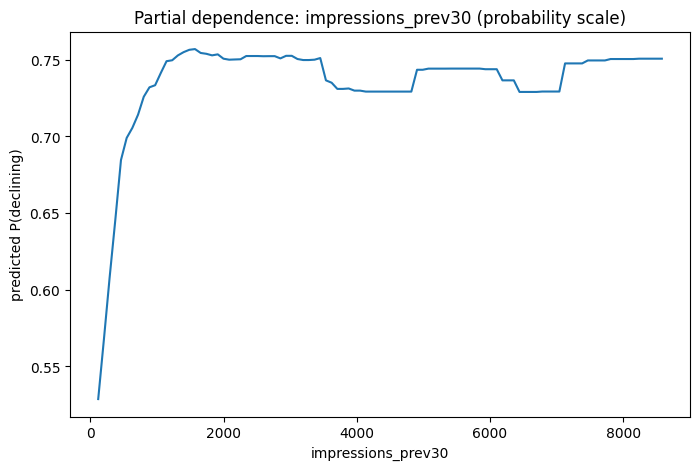

In [28]:
from sklearn.inspection import partial_dependence
from matplotlib import pyplot as plt
pd_result_proba = partial_dependence(
    model_final,
    final.loc[is_test, final_feature_cols],
    features=['impressions_prev30'],
    kind='average',
    method='brute',
    response_method='predict_proba'
)

x_vals = pd_result_proba['grid_values'][0]
y_vals = pd_result_proba['average'][0]

for x, y_ in zip(x_vals[::5], y_vals[::5]):
    print(f"impressions_prev30 = {x:>10.0f}   predicted P(declining) = {y_:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals)
plt.xlabel('impressions_prev30')
plt.ylabel('predicted P(declining)')
plt.title('Partial dependence: impressions_prev30 (probability scale)')
plt.show()

**Two tools, two different jobs — not a winner and a loser.**   
The two ranking methods have very little overlap in their top-500 recommendations in this run (1 of 500, or 0.2%). This shows that the model and baseline prioritize substantially different content items. The baseline favors higher-impression pages because its rule requires at least 500 impressions, while the model also surfaces lower-impression pages. This comparison describes agreement between the two ranking methods; it does not establish that either ranking is causally better or that the model's recommendations will produce better outcomes.

**Confirmed via partial dependence**   
 (brute-force method, which respects feature
correlations — the faster default `'recursion'` method initially suggested a non-monotonic
dip that did not survive this correction and has been discarded): the model's relationship to
`impressions_prev30` is a diminishing-returns curve, not a "sweet spot." Predicted decline
probability rises from ~0.51 near-zero traffic to a plateau of ~0.75-0.77 by roughly 1,400
impressions/30d, then stays essentially flat through 8,500+. Traffic matters most at the low
end; above a moderate threshold, more traffic tells the model very little more about decline
risk. This still differs meaningfully from the baseline rule's linear "bigger = flagged"
logic, which has no plateau and no lower cutoff below 500 impressions at all.

**Recommended use: run both, as separate queues, not one merged ranking.**
- **Baseline queue** — "protect the biggest assets": high-traffic pages showing staleness or
  position weakness. Best when review capacity is small (k=20-50), where Results showed the
  rule's precision is strongest.
- **Model queue** — "catch smaller pages with a risk pattern the rule structurally can't see"
  (anything under the 500-impression floor). Useful when review capacity is larger (k=100+),
  where Results showed the model holds up better, and it surfaces a population the baseline
  never considers at all.

**A weaker signal, named honestly:** `avg_position_prev30` showed *negative* permutation
importance (-0.003) in the final model — scrambling this feature's values didn't hurt
performance, meaning it isn't pulling real weight despite being included by design. Future
iterations should consider dropping it or investigating why position wasn't informative here.

**Reason codes** (baseline queue only, since the model's ranking isn't rule-based):
- `stale_but_visible` — ≥500 impressions/30d, untouched 180+ days
- `position_slipping` — average position worse than the dataset median

**Where to look twice:** items where the baseline rule and the model disagree on whether a
page is worth flagging at all (62,038 of 93,401 — driven mostly by the model's 0.5 threshold
flagging most items given the dataset's 74% base rate, not a true methodological split) are
a less useful cut than the top-500 overlap above; the top-K comparison is the one that
actually reveals the real difference between these two methods.

**No-go list:**
- Do not merge the two queues into one ranking by simply concatenating them — they measure
  different things and a naive merge would misrepresent both.
- No causal or forecasting claim from either method (see Limitations).
- Do not apply outside this dataset without re-running the leakage audit and validation design.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

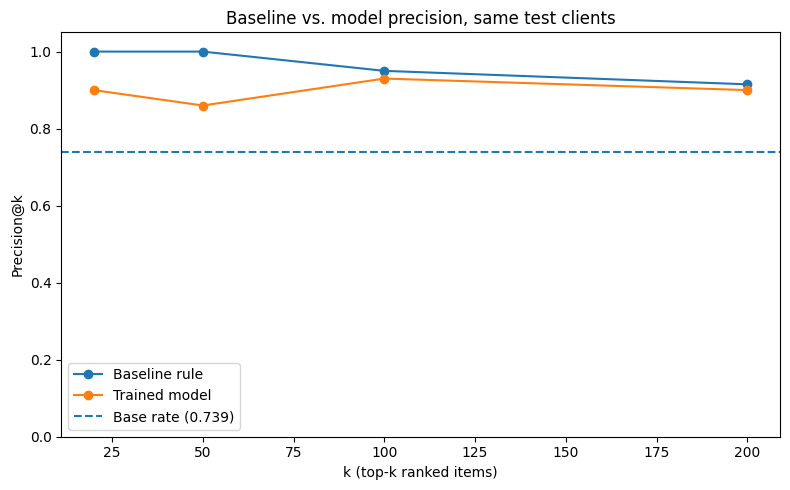

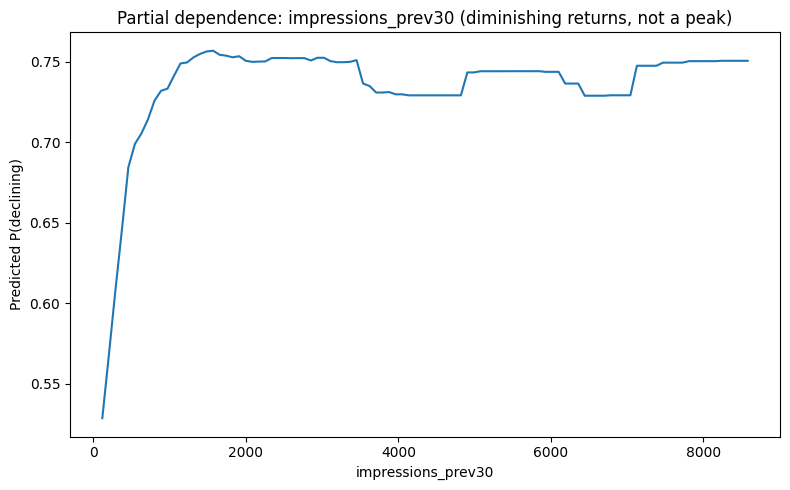

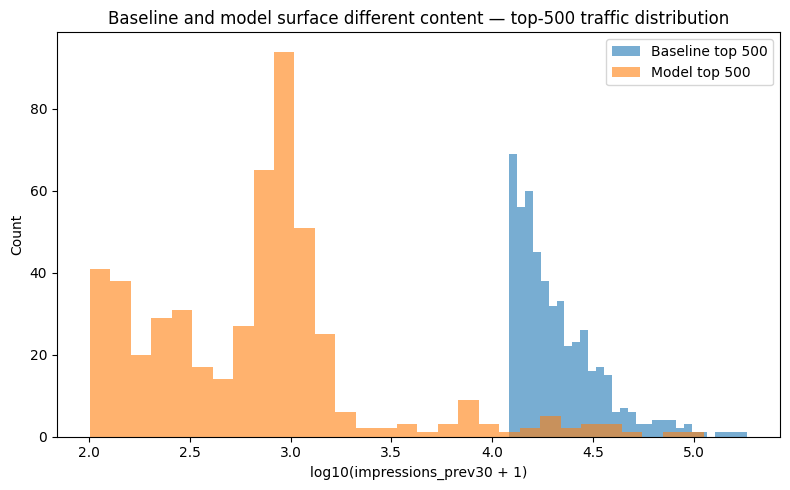

Saved 3 charts to work/outputs/artifacts/


In [29]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import partial_dependence

Path('work/outputs/artifacts').mkdir(parents=True, exist_ok=True)

# ============================================================
# Chart 1: Precision@K comparison
# ============================================================

ks = [20, 50, 100, 200]

baseline_vals = [
    precision_at_k(
        baseline_rule_score[is_test],
        y[is_test].values,
        k
    )
    for k in ks
]

model_vals = [
    precision_at_k(
        probs_final,
        y[is_test].values,
        k
    )
    for k in ks
]

base_rate = y[is_test].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ks,
    baseline_vals,
    marker='o',
    label='Baseline rule'
)

ax.plot(
    ks,
    model_vals,
    marker='o',
    label='Trained model'
)

ax.axhline(
    base_rate,
    linestyle='--',
    label=f'Base rate ({base_rate:.3f})'
)

ax.set_xlabel('k (top-k ranked items)')
ax.set_ylabel('Precision@k')
ax.set_title('Baseline vs. model precision, same test clients')
ax.legend()
ax.set_ylim(0, 1.05)

fig.tight_layout()
fig.savefig(
    'work/outputs/artifacts/precision_at_k.png',
    dpi=150
)
plt.show()


# ============================================================
# Chart 2: Partial dependence
# ============================================================

pd_result_proba = partial_dependence(
    model_final,
    final.loc[is_test, final_feature_cols],
    features=['impressions_prev30'],
    kind='average',
    method='brute',
    response_method='predict_proba'
)

x_vals = pd_result_proba['grid_values'][0]
y_vals = pd_result_proba['average'][0]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x_vals, y_vals)

ax.set_xlabel('impressions_prev30')
ax.set_ylabel('Predicted P(declining)')
ax.set_title(
    'Partial dependence: impressions_prev30 '
    '(diminishing returns, not a peak)'
)

fig.tight_layout()
fig.savefig(
    'work/outputs/artifacts/partial_dependence_impressions.png',
    dpi=150
)
plt.show()


# ============================================================
# Chart 3: Rule vs. model top-500 traffic distribution
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    np.log10(rule_top_df['impressions_prev30'] + 1),
    bins=30,
    alpha=0.6,
    label='Baseline top 500'
)

ax.hist(
    np.log10(model_top_df['impressions_prev30'] + 1),
    bins=30,
    alpha=0.6,
    label='Model top 500'
)

ax.set_xlabel('log10(impressions_prev30 + 1)')
ax.set_ylabel('Count')
ax.set_title(
    'Baseline and model surface different content — '
    'top-500 traffic distribution'
)

ax.legend()

fig.tight_layout()
fig.savefig(
    'work/outputs/artifacts/rule_vs_model_traffic_dist.png',
    dpi=150
)
plt.show()


print("Saved 3 charts to work/outputs/artifacts/")

**Three charts**

1. **`precision_at_k.png`** — baseline vs. model precision at k=20/50/100/200, against the
   test-client base rate. Shows the crossover documented in Results: baseline wins at small k,
   model catches up by k=200.
2. **`partial_dependence_impressions.png`** — the corrected (brute-method) partial dependence
   curve for `impressions_prev30`, showing diminishing returns rather than the initially
   suspected non-monotonic peak.
3. **`rule_vs_model_traffic_dist.png`** — log-scale histogram comparing the traffic level of
   each method's top-500 picks, visualizing the near-total lack of overlap (0.2%) documented
   in Section 6.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.